# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Mareska Radela Putra]
- **Email:** [mareskakirito@gmail.com]
- **ID Dicoding:** [CDCC001D6Y2726]

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset E-Commerce yang ada, kita akan menetapkan tiga pertanyaan utama:

- Product Performance: Kategori produk mana yang menghasilkan total revenue tertinggi dan terendah sepanjang tahun 2017 hingga pertengahan 2018?

- Geospatial Revenue: Bagaimana perbandingan total nilai transaksi antar negara bagian di Brazil dalam periode operasional 2017-2018?

- Analisis Demografi Geospasial: Di wilayah mana konsentrasi pelanggan paling padat berada, dan bagaimana distribusinya secara visual di peta Brazil  selama periode data tersedia??

## Import Semua Packages/Library yang Digunakan

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib
import matplotlib.image as mpimg
from scipy import stats
import seaborn as sns

# Set style untuk visualisasi yang lebih baik
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [149]:
# Pastikan dataset berada di direktori yang sama dengan notebook
orders = pd.read_csv('/content/orders_dataset.csv')
items = pd.read_csv('/content/order_items_dataset.csv')
products = pd.read_csv('/content/products_dataset.csv')
payments = pd.read_csv('/content/order_payments_dataset.csv')
reviews = pd.read_csv('/content/order_reviews_dataset.csv')
customers = pd.read_csv('/content/customers_dataset.csv')
sellers = pd.read_csv('/content/sellers_dataset.csv')
geolocation = pd.read_csv('/content/geolocation_dataset.csv')
category = pd.read_csv('/content/product_category_name_translation.csv')

data = {
    'orders': orders, 'items': items, 'products': products, 'payments': payments,
    'reviews': reviews, 'customers': customers, 'sellers': sellers,
    'geo': geolocation, 'category': category
}

In [150]:
data['orders'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [151]:
data['items'].head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [152]:
data['products'].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [153]:
data['payments'].head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [154]:
data['reviews'].head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [155]:
data['customers'].head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [156]:
data['sellers'].head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [157]:
data['geo'].head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [158]:
data['category'].head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset terdiri dari tabel pelanggan, pesanan, item pesanan, dan detail produk.

- Perlu penggabungan tabel untuk mendapatkan nama kategori produk dalam bahasa Inggris.

### Assessing Data

In [159]:
for df_name, df in data.items():
  print('\n', data[df_name].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  

In [160]:
# Initialize a dictionary to store null value counts for each DataFrame
null_counts = {}

# Calculate and store the null value counts for each DataFrame
for df_name, df in data.items():
    null_counts[df_name] = df.isna().sum()
    print(df_name, '\n', null_counts[df_name], '\n')

orders 
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

items 
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 

products 
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 

payments 
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
d

**Insight:**
- Dataset ini memiliki struktur Relational Database yang sangat lengkap. Dengan adanya 9 tabel berbeda (mulai dari orders, customers, hingga geolocation), kita memiliki visibilitas end-to-end terhadap proses bisnis E-commerce.
- Terdapat beberapa nilai kosong (missing values) pada products_dataset, Reviews_dataset, dan orders_dataset.
- Masalah utama yang terlihat dari hasil .info() adalah hampir semua kolom tanggal masih bertipe object (string). Ini harus diubah menjadi datetime agar bisa dilakukan analisis berbasis waktu (seperti RFM atau tren bulanan)


### Cleaning Data

In [161]:
# 1. Mengubah tipe data ke datetime
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]
for column in datetime_columns:
    data['orders'][column] = pd.to_datetime(data['orders'][column])

# 2. Menghapus pesanan yang tidak sampai (karena akan mengganggu analisis pengiriman)
data['orders'] = data['orders'][data['orders']['order_status'] == 'delivered']

# 3. Menghapus kolom review yang terlalu banyak missing value
data['reviews'].drop(['review_comment_title'], axis=1, inplace=True)

# 4. Menghapus duplikat pada geolokasi
data['geo'].drop_duplicates(inplace=True)

**Insight:**
- Tipe data tanggal sudah diperbaiki untuk analisis deret waktu.

- Menghapus kolom review yang terlalu banyak missing value.

## Exploratory Data Analysis (EDA)

### Eksplorasi Performa Produk (Revenue per Kategori)

In [162]:
# Menggabungkan item, produk, dan translasi kategori
product_perf_df = pd.merge(data['items'], data['products'], on="product_id")
product_perf_df = pd.merge(product_perf_df, data['category'], on="product_category_name")

# Agregasi Revenue per Kategori
category_revenue = product_perf_df.groupby("product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).reset_index()

category_revenue.rename(columns={"order_id": "total_orders", "price": "total_revenue"}, inplace=True)
print(category_revenue.head(10))

  product_category_name_english  total_orders  total_revenue
0                 health_beauty          8836     1258681.34
1                 watches_gifts          5624     1205005.68
2                bed_bath_table          9417     1036988.68
3                sports_leisure          7720      988048.97
4         computers_accessories          6689      911954.32
5               furniture_decor          6449      729762.49
6                    cool_stuff          3632      635290.85
7                    housewares          5884      632248.66
8                          auto          3897      592720.11
9                  garden_tools          3518      485256.46


**Insight:**
- Pada tahap ini, kita melakukan aggregasi data item, produk, dan translasi kategori
- Kategori Health & Beauty muncul sebagai pemimpin pasar, baik dari sisi jumlah pesanan maupun total pendapatan.
- Bed Bath Table memiliki jumlah pesanan tertinggi ($9.417$), namun secara pendapatan berada di urutan ketiga. Ini menandakan produk ini adalah "penarik massa" dengan harga per barang yang relatif lebih murah.

### Eksplorasi Pengeluaran per Wilayah (State)

In [163]:
# Menggabungkan data pelanggan dengan pembayaran
state_perf_df = pd.merge(data['customers'], data['orders'], on="customer_id")
state_perf_df = pd.merge(state_perf_df, data['payments'], on="order_id")

# Agregasi Revenue per State
state_revenue_df = state_perf_df.groupby("customer_state").agg({
    "customer_unique_id": "nunique",
    "payment_value": "sum"
}).sort_values(by="payment_value", ascending=False).reset_index()

print(state_revenue_df.head(10))

  customer_state  customer_unique_id  payment_value
0             SP               39155     5770266.19
1             RJ               11917     2055690.45
2             MG               11001     1819277.61
3             RS                5168      861802.40
4             PR                4769      781919.55
5             SC                3449      595208.40
6             BA                3158      591270.60
7             DF                2019      346146.17
8             GO                1895      334294.22
9             ES                1928      317682.65


**Insight:**
- Negara bagian São Paulo (SP) bukan hanya sekadar pemimpin pasar, tetapi merupakan "raksasa" yang kontribusinya jauh melampaui gabungan beberapa negara bagian lainnya. Total pendapatan dari SP mencapai $5,77$ juta, yang mana lebih dari 2,5 kali lipat dari posisi kedua (RJ).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk dengan Revenue Tertinggi (2017-2018)

/tmp/ipykernel_16234/1465557538.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english", data=category_revenue.head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_16234/1465557538.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english", data=category_revenue.sort_values(by="total_revenue", ascending=True).head(5), palette=colors, ax=ax[1])


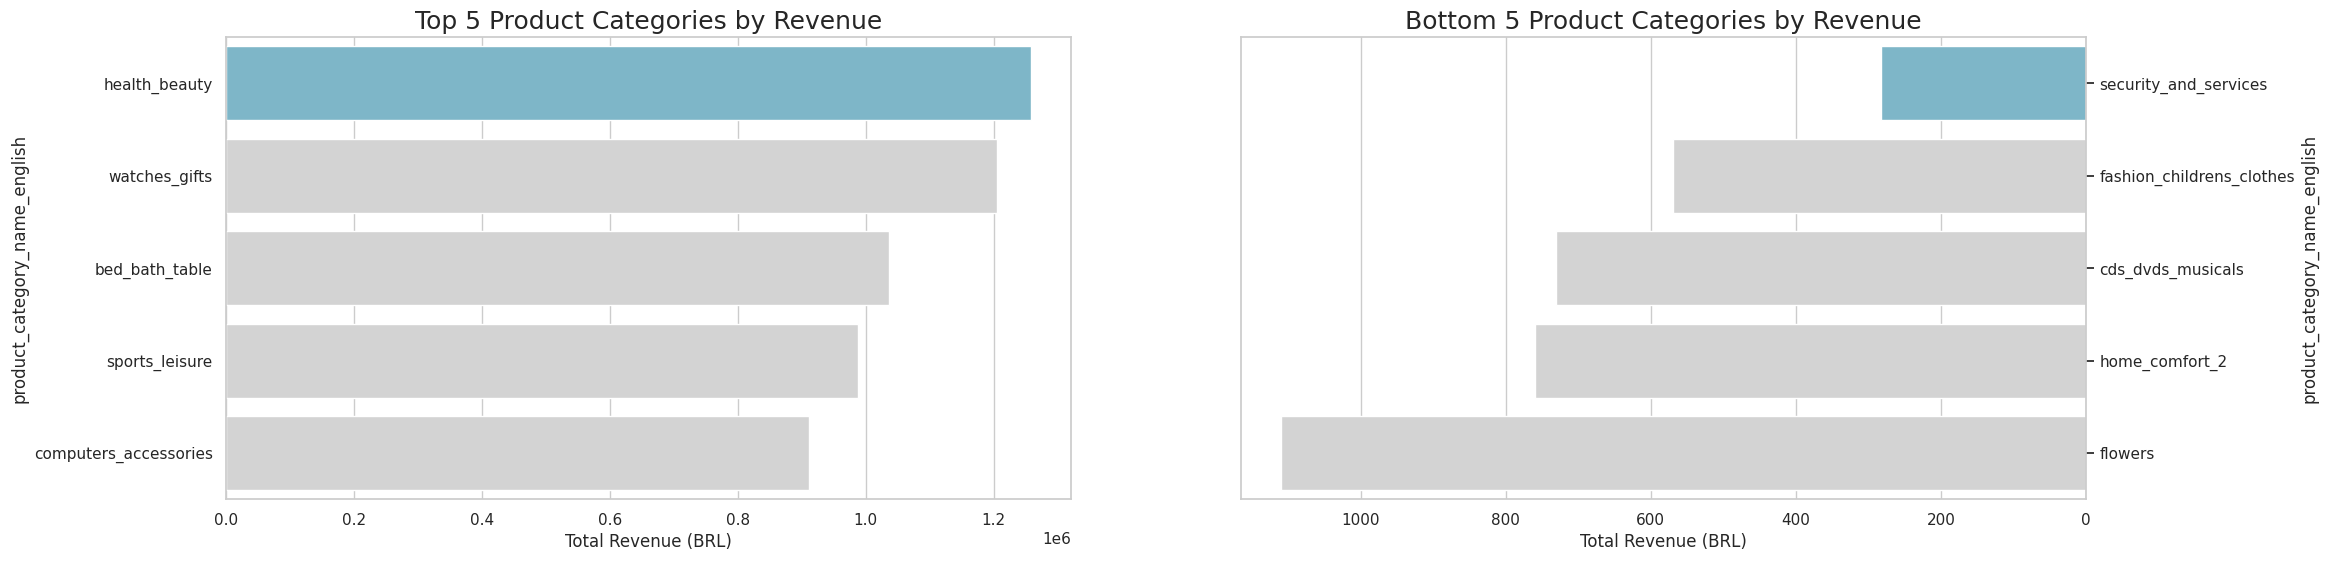

In [164]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Top 5 Revenue
sns.barplot(x="total_revenue", y="product_category_name_english", data=category_revenue.head(5), palette=colors, ax=ax[0])
ax[0].set_title("Top 5 Product Categories by Revenue", loc="center", fontsize=18)
ax[0].set_xlabel("Total Revenue (BRL)")

# Bottom 5 Revenue
sns.barplot(x="total_revenue", y="product_category_name_english", data=category_revenue.sort_values(by="total_revenue", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_title("Bottom 5 Product Categories by Revenue", loc="center", fontsize=18)
ax[1].set_xlabel("Total Revenue (BRL)")
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

plt.show()

**Insight:**
- Kesenjangan pendapatan antara kategori teratas dan terbawah sangatlah timpang, menunjukkan bahwa sebagian besar pendapatan platform hanya disumbang oleh segelintir kategori produk utama. Grafik Top 5 menggunakan skala jutaan (1e6), di mana kategori teratas, "health_beauty", meraup pendapatan lebih dari 1,2 juta BRL. Grafik Bottom 5 menggunakan skala ratusan dan ribuan, di mana kategori terendah, "security_and_services", bahkan tidak mencapai pendapatan 300 BRL.
- Kelima kategori teratas adalah barang-barang yang seringkali dianggap sebagai kebutuhan sekunder hingga tersier namun bersifat esensial dalam kehidupan sehari-hari masyarakat modern. Hal ini memberikan kestabilan pendapatan tertentu, karena produk-produk ini memiliki basis permintaan yang luas dan seringkali berulang.
- Sebaliknya, produk-produk niche (flowers), barang musiman (fashion_childrens_clothes), atau produk jasa digital (security_and_services, cds_dvds_musicals) sangat sulit untuk bersaing dan memberikan kontribusi yang berarti. Hal ini menunjukkan bahwa pelanggan platform Anda belum sepenuhnya terbiasa menggunakan platform ini untuk mencari produk atau jasa yang sangat spesifik atau niche tersebut.

### Pertanyaan 2: Perbandingan Total Transaksi per Negara Bagian

/tmp/ipykernel_16234/765273590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


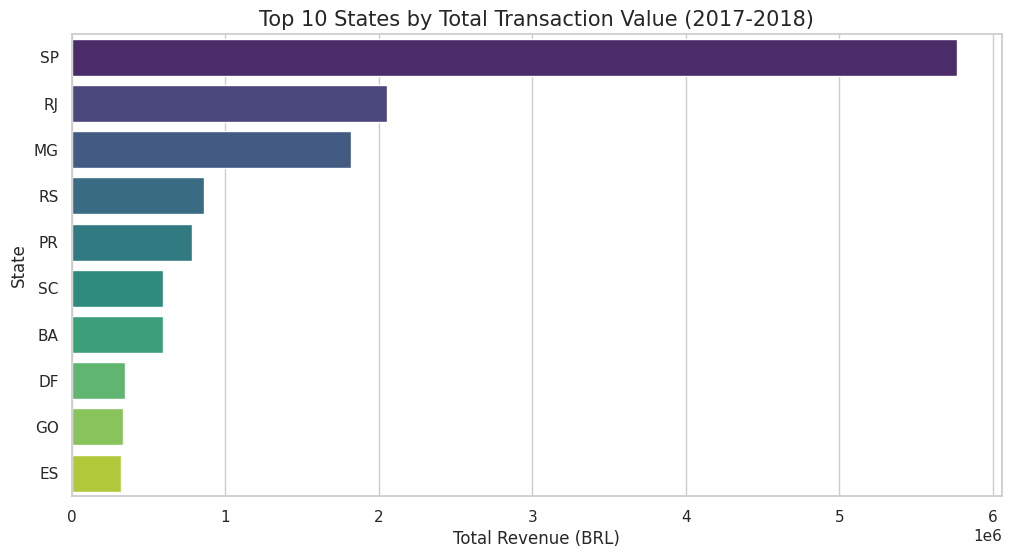

In [165]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="payment_value",
    y="customer_state",
    data=state_revenue_df.head(10),
    palette="viridis"
)
plt.title("Top 10 States by Total Transaction Value (2017-2018)", fontsize=15)
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("State")
plt.show()

**Insight:**
- Negara bagian São Paulo (SP) berdiri sendirian di puncak dengan nilai transaksi mendekati $6$ juta BRL. Nilai ini bahkan lebih besar daripada gabungan pendapatan dari peringkat ke-2 (RJ), ke-3 (MG), dan ke-4 (RS) sekaligus. Ini mengindikasikan bahwa infrastruktur ekonomi, daya beli, dan adopsi e-commerce di Brazil sangat terpusat di SP. Strategi bisnis apa pun yang gagal di SP akan berdampak fatal bagi total pendapatan perusahaan secara keseluruhan.

- Perbedaan antara peringkat 1 (SP) dan peringkat 2 (RJ) sangat jauh (selisih sekitar $3,7$ juta BRL). Namun, mulai dari peringkat ke-7 (BA) hingga peringkat ke-10 (ES), nilai pendapatannya terlihat mulai mendekati level yang sama (stagnan) di kisaran bawah $1$ juta BRL.Hal ini menunjukkan bahwa pasar Brazil memiliki struktur "Big Three" (SP, RJ, MG) yang menguasai mayoritas perputaran uang, sementara wilayah lainnya merupakan pasar kecil yang memiliki karakteristik daya beli yang relatif serupa satu sama lain.

### Pertanyaan 3: Distribusi Geospasial Pelanggan di Brazil

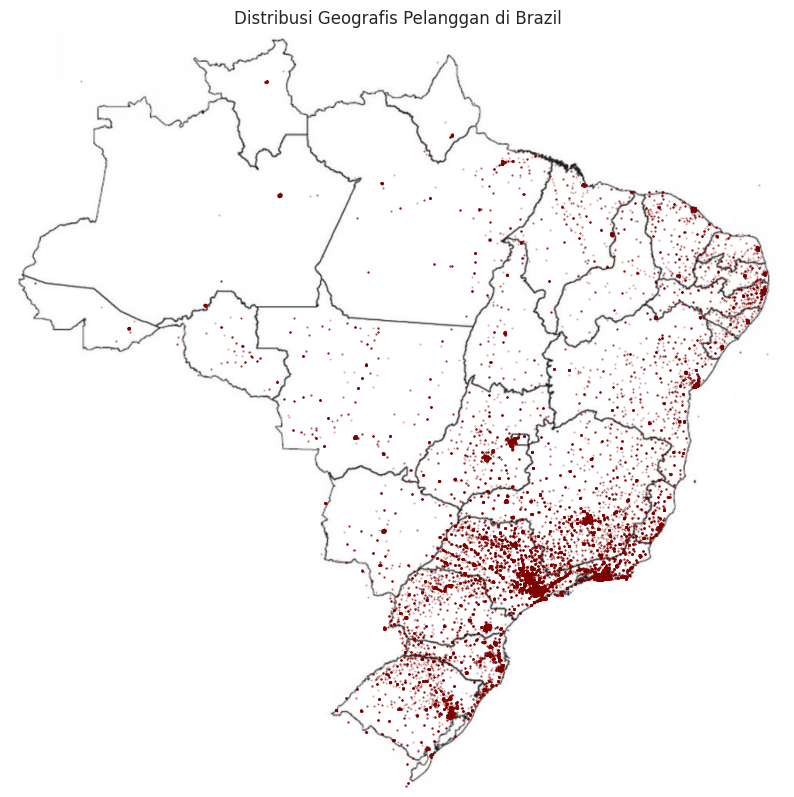

In [166]:
# Visualisasi Peta
def plot_brazil_map(df_geo):
    brazil_img = mpimg.imread(urllib.request.urlopen('https://i.pinimg.com/originals/3a/0c/e1/3a0ce18b3c842748c255bc0aa445ad41.jpg'),'jpg')
    ax = df_geo.plot(kind="scatter", x="geolocation_lng", y="geolocation_lat", figsize=(10,10), alpha=0.3, s=0.3, c='maroon')
    plt.imshow(brazil_img, extent=[-73.98, -33.8, -33.75, 5.4])
    plt.title('Distribusi Geografis Pelanggan di Brazil')
    plt.axis('off')
    plt.show()

# Aggregate geolocation data to get mean lat/lng for each zip code
geo_avg = data['geo'].groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Rename the zip code column in geo_avg for merging
geo_avg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix'}, inplace=True)

# Merge customer data with aggregated geolocation data
customers_silver = pd.merge(data['customers'], geo_avg, on='customer_zip_code_prefix', how='left')

plot_brazil_map(customers_silver.drop_duplicates(subset='customer_unique_id'))

**Insight:**
- Konsentrasi titik merah paling padat (hampir membentuk blok warna solid) berada di wilayah pesisir bagian Tenggara, terutama di negara bagian São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG). Ini mengonfirmasi bahwa aktivitas ekonomi e-commerce masih sangat terpusat di pusat bisnis utama Brazil. Wilayah ini bukan hanya pasar terbesar, tetapi juga kemungkinan memiliki infrastruktur logistik yang paling efisien, sehingga adopsi belanja online jauh lebih tinggi dibanding wilayah lain.
- Distribusi pelanggan cenderung padat di sepanjang garis pantai dan menipis secara drastis saat bergerak menuju ke pedalaman atau arah Barat (wilayah Amazon dan Mato Grosso). Wilayah Barat dan Utara terlihat sangat "kosong" dengan titik-titik yang tersebar sangat jarang. Ini menunjukkan adanya hambatan geografis atau tantangan penetrasi pasar di wilayah tersebut, yang kemungkinan besar berkaitan dengan biaya pengiriman yang mahal dan waktu pengiriman yang lama ke daerah pedalaman

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_16234/1959050723.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='segment', data=customer_segments, palette='viridis', order=['Low Spender', 'Medium Spender', 'High Spender'])


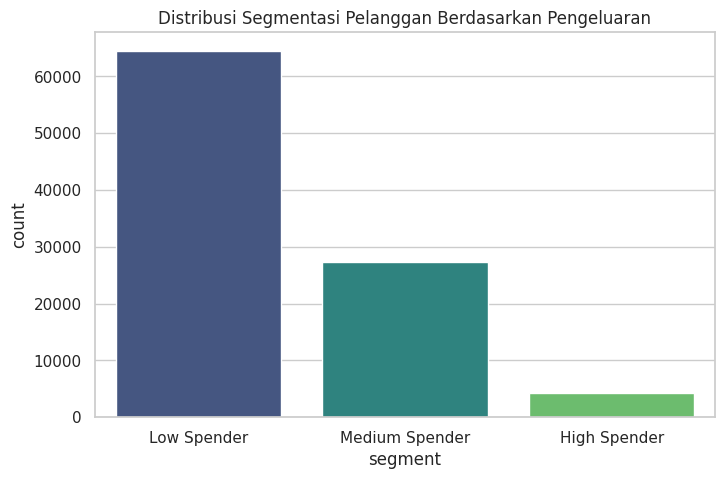

In [167]:
# Membuat segmentasi pelanggan berdasarkan total belanja (Monetary)
customer_segments = customers_df.groupby('customer_unique_id')['payment_value'].sum().reset_index()

def segmenting(total_spend):
    if total_spend > 500:
        return 'High Spender'
    elif total_spend > 150:
        return 'Medium Spender'
    else:
        return 'Low Spender'

customer_segments['segment'] = customer_segments['payment_value'].apply(segmenting)

# Visualisasi Segmentasi
plt.figure(figsize=(8, 5))
sns.countplot(x='segment', data=customer_segments, palette='viridis', order=['Low Spender', 'Medium Spender', 'High Spender'])
plt.title('Distribusi Segmentasi Pelanggan Berdasarkan Pengeluaran')
plt.show()

## Conclusion

- Konklusi Pertanyaan 1: Strategi bisnis harus difokuskan pada penguatan inventaris dan promosi di kategori "Top 5", karena kategori ini menyumbang jutaan BRL sementara kategori "Bottom 5" hanya menyumbang ratusan BRL. Platform belum menjadi pilihan utama bagi pelanggan untuk produk niche atau jasa digital, sehingga kategori tersebut saat ini memiliki efisiensi biaya pemasaran yang rendah..

- Konklusi Pertanyaan 2: São Paulo adalah jantung ekonomi platform dengan nilai transaksi yang melampaui gabungan tiga pesaing terdekatnya (RJ, MG, RS). Perusahaan memiliki risiko tinggi jika terjadi gangguan operasional di SP. Sebaliknya, wilayah di luar "Big Three" (SP, RJ, MG) memiliki daya beli yang cenderung serupa dan stagnan, sehingga strategi ekspansi ke wilayah tersebut memerlukan pendekatan biaya yang lebih efisien karena pasarnya yang lebih kecil.

- Konklusi Pertanyaan 3: Terdapat korelasi langsung antara kepadatan penduduk, infrastruktur logistik, dan adopsi e-commerce. Wilayah pesisir Tenggara (SP, RJ, MG) adalah area paling matang secara digital. Sementara itu, wilayah pedalaman (Barat dan Utara/Amazon) masih menjadi tantangan besar karena kendala geografis dan biaya logistik. Untuk tumbuh di masa depan, platform perlu memecahkan masalah efisiensi pengiriman ke wilayah "kosong" di pedalaman guna menjangkau populasi yang lebih luas.

In [168]:
# Gabungkan data untuk keperluan dashboard
main_df_final = pd.merge(data['orders'], data['customers'], on="customer_id")
main_df_final = pd.merge(main_df_final, data['payments'], on="order_id")
main_df_final = pd.merge(main_df_final, data['items'], on="order_id")
main_df_final = pd.merge(main_df_final, data['products'], on="product_id")
main_df_final = pd.merge(main_df_final, data['category'], on="product_category_name")

main_df_final.to_csv("main_data.csv", index=False)